Dataset chosen: Shark attacks and fatalities dataset.

 I wanted a dataset of shark attacks because they're more interesting to me and Im going to be home this summer in the ocean water.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
url = "https://raw.githubusercontent.com/owid/owid-datasets/master/datasets/Shark%20attacks%20and%20fatalities%20-%20Global%20Shark%20Attack%20File%20%28GSAF%29%20%282018%29%20/Shark%20attacks%20and%20fatalities%20-%20Global%20Shark%20Attack%20File%20%28GSAF%29%20%282018%29%20.csv"
df = pd.read_csv(url)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   Entity                                                 2018 non-null   object
 1   Year                                                   2018 non-null   int64 
 2   Total number of shark attacks (GSAF (2018))            2018 non-null   int64 
 3   Total number of shark attack fatalities (GSAF (2018))  2018 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 63.2+ KB


In [6]:
df.describe()

,Year,Total number of shark attacks (GSAF (2018)),Total number of shark attack fatalities (GSAF (2018))
count,2018.000000,2018.000000,2018.000000
mean,1927.834490,5.640238,1.346878
std,166.772882,13.487334,2.465346
min,-725.000000,1.000000,0.000000
25%,1901.250000,1.000000,0.000000
50%,1953.000000,1.000000,1.000000
75%,1988.000000,4.000000,1.000000
max,2018.000000,131.000000,24.000000


In [7]:
df.head()

,Entity,Year,Total number of shark attacks (GSAF (2018)),Total number of shark attack fatalities (GSAF (2018))
0,Admiralty Islands,1962,1,0
1,Algeria,1844,1,1
2,American Samoa,1954,1,1
3,American Samoa,1955,1,1
4,American Samoa,1958,1,1


In [8]:
df.shape

(2018, 4)

In [9]:
df.columns

Index(['Entity', 'Year', 'Total number of shark attacks (GSAF (2018))',
       'Total number of shark attack fatalities (GSAF (2018))'],
      dtype='object')

**Which countries and activities are most associated with recorded shark attacks, and how have attacks changed over time?**

In [10]:
df.isnull().sum()

,0
Entity,0
Year,0
Total number of shark attacks (GSAF (2018)),0
Total number of shark attack fatalities (GSAF (2018)),0


In [14]:
df = df.dropna(subset=[
    "Entity",
    "Year",
    "Total number of shark attacks (GSAF (2018))",
    "Total number of shark attack fatalities (GSAF (2018))"
])

df = df.drop_duplicates()
df.shape

(2018, 4)

In [15]:
top_countries = df.groupby("Entity")["Total number of shark attacks (GSAF (2018))"].sum().sort_values(ascending=False).head(10)
top_countries

,Total number of shark attacks (GSAF (2018))
Entity,
World,5691
United States,2033
Australia,1212
South Africa,512
Papua New Guinea,132
New Zealand,116
Bahamas,104
Brazil,101
Mexico,78


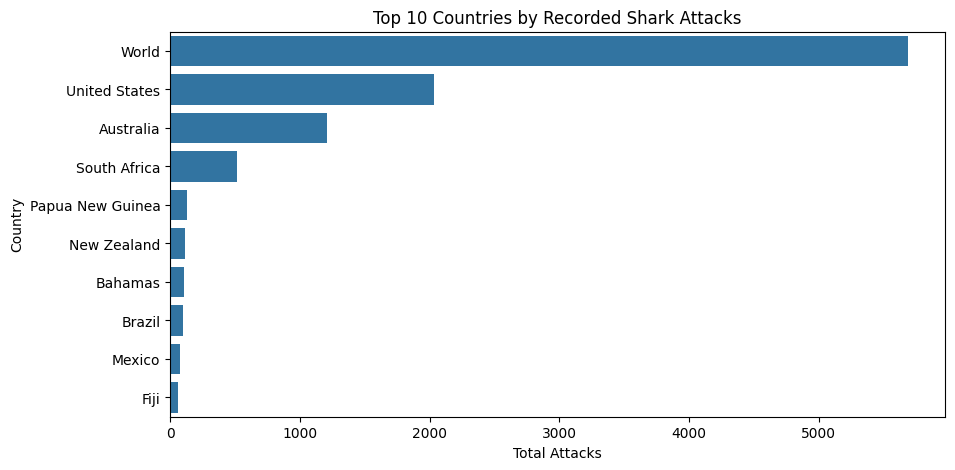

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Recorded Shark Attacks")
plt.xlabel("Total Attacks")
plt.ylabel("Country")
plt.show()

In [17]:
yearly_attacks = df.groupby("Year")[[
    "Total number of shark attacks (GSAF (2018))",
    "Total number of shark attack fatalities (GSAF (2018))"
]].sum().reset_index()

yearly_attacks.head()

,Year,Total number of shark attacks (GSAF (2018)),Total number of shark attack fatalities (GSAF (2018))
0,-725,2,2
1,-493,2,2
2,-336,2,2
3,5,2,0
4,500,2,0


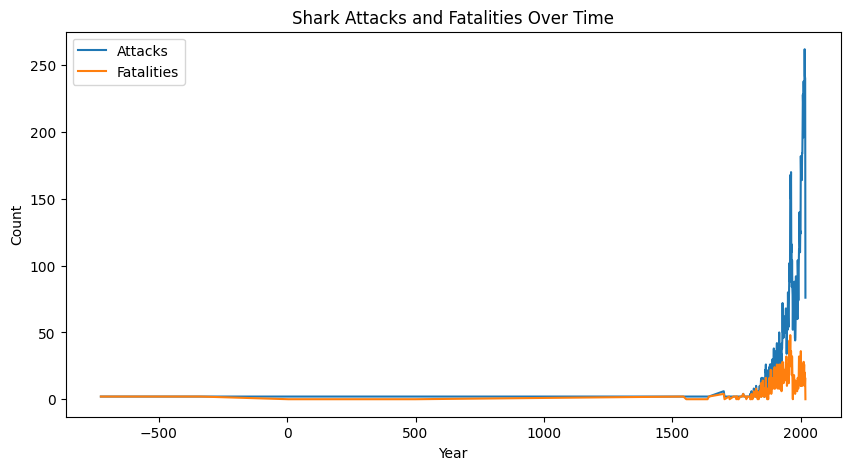

In [18]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=yearly_attacks,
    x="Year",
    y="Total number of shark attacks (GSAF (2018))",
    label="Attacks"
)
sns.lineplot(
    data=yearly_attacks,
    x="Year",
    y="Total number of shark attack fatalities (GSAF (2018))",
    label="Fatalities"
)
plt.title("Shark Attacks and Fatalities Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

This dataset does a pretty good job answering my question because it shows country names, years, attack counts, and fatality counts all in one place. The bar chart makes it easy to see which countries show up the most in recorded shark attacks, and the line graph helps show how attacks and fatalities change over time. Looking at both together gives a clearer picture of where attacks are happening and whether the numbers seem to rise or fall over the years.

What stood out to me most is that the countries with the most attacks are not always the same ones with the most fatalities. That makes the data more interesting because it shows that attack frequency and danger are not exactly the same thing. I also noticed that trends over time can be hard to read as just one simple story, since part of it could be real changes and part of it could be better reporting. One limitation is that this dataset is still pretty broad, so it does not really explain what people were doing, the shark species, or the exact situation. If I kept going with this, I would want more detailed information about activity, location, and what made some attacks more serious than others.